# Outliers univariantes, patrones simples y técnicas estadísticas

**Índice**
1. Outliers del importe: boxplots, Z-score e IQR
2. Patrones simples de fraude
3. Técnicas estadísticas para detección de anomalías (incluye la referencia en test para los hitos 3 y 4)
4. Carga de trabajo para los analistas

Los apartados 1, 2 y 3.1-3.6 son exploratorios: se calculan sobre todo el histórico y los umbrales se eligen mirando la etiqueta, así que sus cifras son optimistas. La referencia comparable con los modelos está en el apartado 3.7, que se ajusta en train y se mide en test.

## Conexión y carga

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import clickhouse_connect
from sklearn.metrics import average_precision_score, roc_auc_score
sys.path.insert(0, '..')

AZUL = "#2b6cb0"
AZULES = "Blues_r"
CLASES = {"normal": "#9ecae1", "fraude": "#08306b"}
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
from config import CONFIG, HOST, PORT, USER, PASSWORD, DATABASE
client = clickhouse_connect.get_client(
    host=HOST, port=PORT, username=USER, password=PASSWORD, database=DATABASE
)

# Orden estable por (timestamp, transaccion_id): con empates en timestamp, ordenar solo por fecha
# daría un orden (y un corte train/test) distinto en cada ejecución
df = (client.query_df("SELECT * FROM features_transaccion")
        .sort_values(["timestamp", "transaccion_id"], kind="stable")
        .reset_index(drop=True))
df["clase"] = df["es_fraude"].map({1: "fraude", 0: "normal"})
TOTAL_FRAUDE = int(df["es_fraude"].sum())
print(f"{len(df):,} transacciones, {TOTAL_FRAUDE} fraudulentas ({df['es_fraude'].mean() * 100:.2f} %)")

# Misma partición temporal que preparacion_datos_ml.py: se descartan los días de calentamiento,
# el 70 % más antiguo es train y el resto test. Se usa en el apartado 3.7
inicio = df["timestamp"].min() + pd.Timedelta(days=CONFIG["preparacion"]["dias_calentamiento"])
utiles = df.index[df["timestamp"] >= inicio]
corte = utiles[int(len(utiles) * CONFIG["preparacion"]["proporcion_train"])]
df["parte"] = np.select([df.index < utiles[0], df.index < corte], ["calentamiento", "train"], "test")
print(df.groupby("parte", sort=False)["es_fraude"].agg(transacciones="size", fraudes="sum"))

# Comprobación: la BD tiene que ser la misma de la que salieron los parquets de los modelos
ids_test = pd.read_parquet("../datos_ml/info_test.parquet", columns=["transaccion_id"])["transaccion_id"]
iguales = set(ids_test) == set(df.loc[df["parte"] == "test", "transaccion_id"])
print(f"\nEl test coincide con el de datos_ml/: {iguales}")

def evaluar(marcadas, nombre, datos=None):
    """Precisión y recall de una marca booleana sobre `datos` (por defecto, todo el histórico)."""
    datos = df if datos is None else datos
    marcadas = marcadas.loc[datos.index]
    total = int(datos["es_fraude"].sum())
    n = int(marcadas.sum())
    vp = int((marcadas & (datos["es_fraude"] == 1)).sum())
    return {"método": nombre, "marcadas": n, "% del total": n / len(datos) * 100,
            "fraude detectado": vp, "precisión %": vp / n * 100 if n else 0,
            "recall %": vp / total * 100}

39,839 transacciones, 703 fraudulentas (1.76 %)
               transacciones  fraudes
parte                                
calentamiento           6729        0
train                  23177      481
test                    9933      222

El test coincide con el de datos_ml/: True


## 1. Outliers univariantes del importe

### 1.1 Boxplots

Un boxplot marca como outliers los puntos fuera de los bigotes. A la izquierda, la cantidad tal cual. A la derecha, en escala logarítmica. Como el importe es muy asimétrico, en escala lineal casi todo queda aplastado abajo y cientos de transacciones normales salen como outliers.

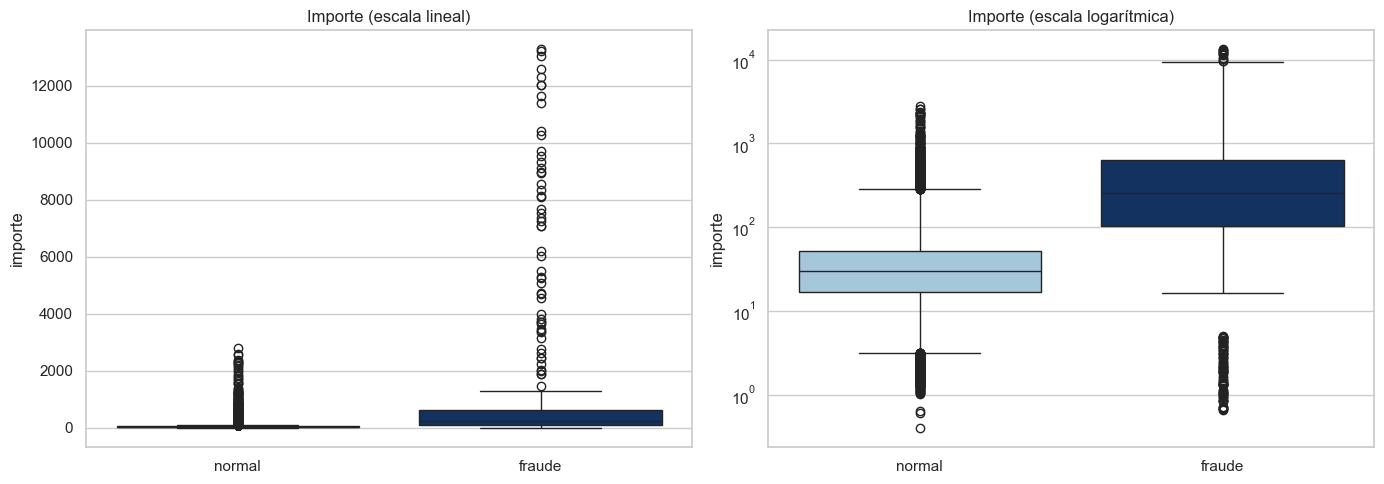

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="clase", y="importe", hue="clase", order=["normal", "fraude"],
            palette=CLASES, legend=False, ax=axes[0])
axes[0].set_title("Importe (escala lineal)")
axes[0].set_xlabel("")
sns.boxplot(data=df, x="clase", y="importe", hue="clase", order=["normal", "fraude"],
            palette=CLASES, legend=False, log_scale=True, ax=axes[1])
axes[1].set_title("Importe (escala logarítmica)")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

### 1.2 Z-score e IQR

- Z-score global: |z| > 3, con z = (importe − media) / desviación. Asume una distribución normal.
- Z-score global sobre log(importe): lo mismo, pero sobre el logaritmo, que es mucho más simétrico.
- IQR global: fuera de [Q1 − 1,5·IQR, Q3 + 1,5·IQR]. No asume normalidad.
- IQR global sobre log(importe).
- Z-score por cliente (z_importe_cliente > 3): compara el importe con el historial de ese cliente, usando solo sus compras anteriores.

Precisión: de las transacciones marcadas, qué % es fraude. 
Recall: del fraude total, qué % se marca.

In [3]:
def z_score(x):
    return (x - x.mean()) / x.std()

def fuera_iqr(x, k=1.5):
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (x < q1 - k * iqr) | (x > q3 + k * iqr)

metodos = {
    "Z-score global": z_score(df["importe"]).abs() > 3,
    "Z-score global (log)": z_score(df["log_importe"]).abs() > 3,
    "IQR global": fuera_iqr(df["importe"]),
    "IQR global (log)": fuera_iqr(df["log_importe"]),
    "Z-score por cliente": df["z_importe_cliente"] > 3,
}
comparativa = pd.DataFrame([evaluar(m, nombre) for nombre, m in metodos.items()])

q1, q3 = df["importe"].quantile([0.25, 0.75])
print(f"Media: {df['importe'].mean():.2f} €   Desviación: {df['importe'].std():.2f} €   "
      f"-> umbral Z-score: {df['importe'].mean() + 3 * df['importe'].std():.2f} €")
print(f"Q1: {q1:.2f} €   Q3: {q3:.2f} €   IQR: {q3 - q1:.2f} €   -> umbral IQR: {q3 + 1.5 * (q3 - q1):.2f} €\n")
comparativa.round(1)

Media: 59.73 €   Desviación: 293.89 €   -> umbral Z-score: 941.41 €
Q1: 17.07 €   Q3: 53.88 €   IQR: 36.81 €   -> umbral IQR: 109.09 €



,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,Z-score global,155,0.4,108,69.7,15.4
1,Z-score global (log),387,1.0,220,56.8,31.3
2,IQR global,2996,7.5,516,17.2,73.4
3,IQR global (log),887,2.2,365,41.1,51.9
4,Z-score por cliente,578,1.5,199,34.4,28.3


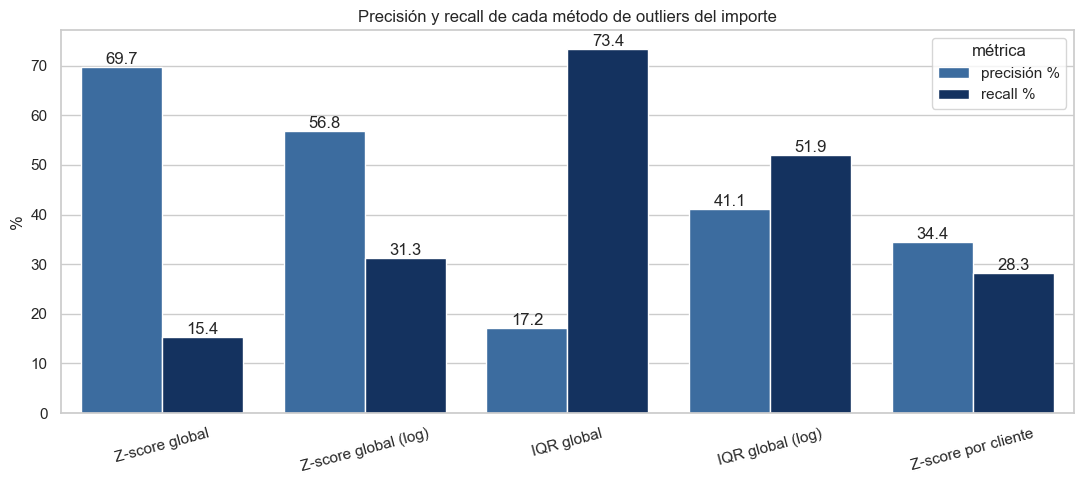

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
comp_larga = comparativa.melt(id_vars="método", value_vars=["precisión %", "recall %"],
                              var_name="métrica", value_name="valor")
sns.barplot(data=comp_larga, x="método", y="valor", hue="métrica",
            palette=[AZUL, "#08306b"], ax=ax)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f")
ax.set_title("Precisión y recall de cada método de outliers del importe")
ax.set_xlabel("")
ax.set_ylabel("%")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

**Z-score global**: la precisión más alta (69,7 %), pero el recall más bajo (15,4 %). Con una desviación de 294 € el umbral sube a 941 €, así que solo caza importes enormes.

**IQR global**: el mayor recall (73,4 %), pero con un 17,2 % de precisión, porque marca el 7,5 % de todas las transacciones. Sobre el importe sin transformar, cualquier compra por encima de 109 € es "outlier".

**Escala logarítmica**: el IQR sobre log(importe) es el más equilibrado (41,1 % de precisión y 51,9 % de recall). El Z-score sobre el log queda entre medias (56,8 % y 31,3 %).

### 1.3 ¿Qué tipos de fraude detecta cada método?

Porcentaje de las transacciones de cada tipo de fraude que marca cada método. Un método de outliers del importe solo puede detectar los fraudes con importes raros.

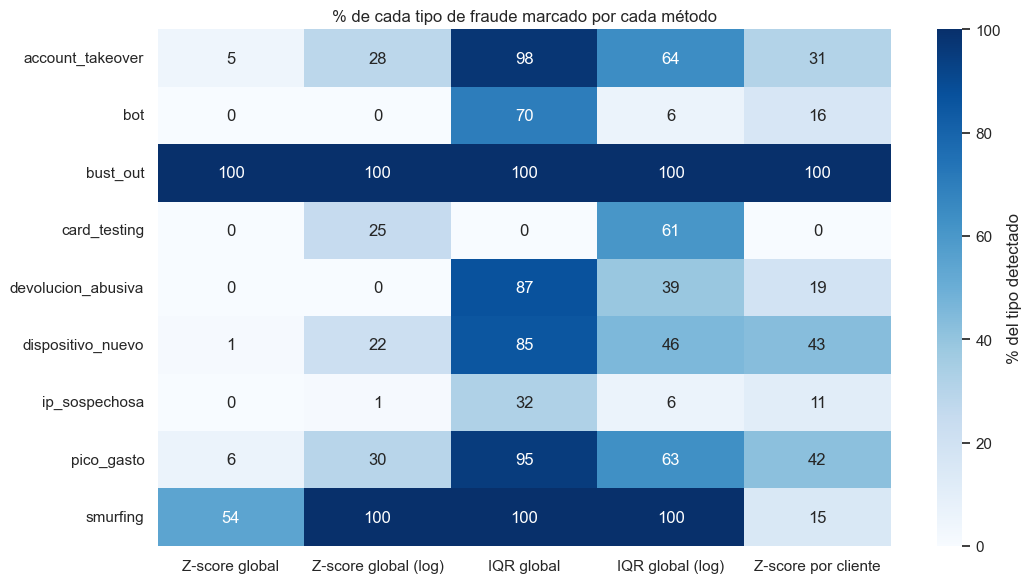

,Z-score global,Z-score global (log),IQR global,IQR global (log),Z-score por cliente
tipo_fraude,,,,,
account_takeover,5.0,28.0,98.0,64.0,31.0
bot,0.0,0.0,70.0,6.0,16.0
bust_out,100.0,100.0,100.0,100.0,100.0
card_testing,0.0,25.0,0.0,61.0,0.0
devolucion_abusiva,0.0,0.0,87.0,39.0,19.0
dispositivo_nuevo,1.0,22.0,85.0,46.0,43.0
ip_sospechosa,0.0,1.0,32.0,6.0,11.0
pico_gasto,6.0,30.0,95.0,63.0,42.0
smurfing,54.0,100.0,100.0,100.0,15.0


In [5]:
fraude = df[df["es_fraude"] == 1]
por_tipo = pd.DataFrame({nombre: m[fraude.index].groupby(fraude["tipo_fraude"]).mean() * 100
                         for nombre, m in metodos.items()})
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(por_tipo, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100,
            cbar_kws={"label": "% del tipo detectado"}, ax=ax)
ax.set_title("% de cada tipo de fraude marcado por cada método")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

por_tipo.round(0)

Los métodos globales detectan bien el bust-out y el smurfing (importes muy altos): el 100 % con casi todos.

El card testing (importes de unos 2 €) solo lo detectan los métodos sobre el logaritmo (61 % con el IQR log): en escala logarítmica los importes muy pequeños quedan tan lejos del centro como los muy grandes, y salen por la cola baja.

El IQR global marca más del 85 % de casi todos los tipos, pero no porque los distinga: marca cualquier compra por encima de 109 €, el 7,5 % del total.

La IP sospechosa casi no se detecta con ningún método (6-11 %, salvo ese 32 % del IQR global), porque sus importes son normales.

### 1.4. Outliers en otras variables

Boxplots de otras variables numéricas por clase. Las variables de sesión (eventos por sesión, intentos de login) solo existen en los pagos online: features.py pone un 0 a los pagos con datáfono, que significa "no aplica" y no "pocos". Por eso estas dos variables se analizan solo con los pagos online; si no, todos los pagos presenciales saldrían como outliers.

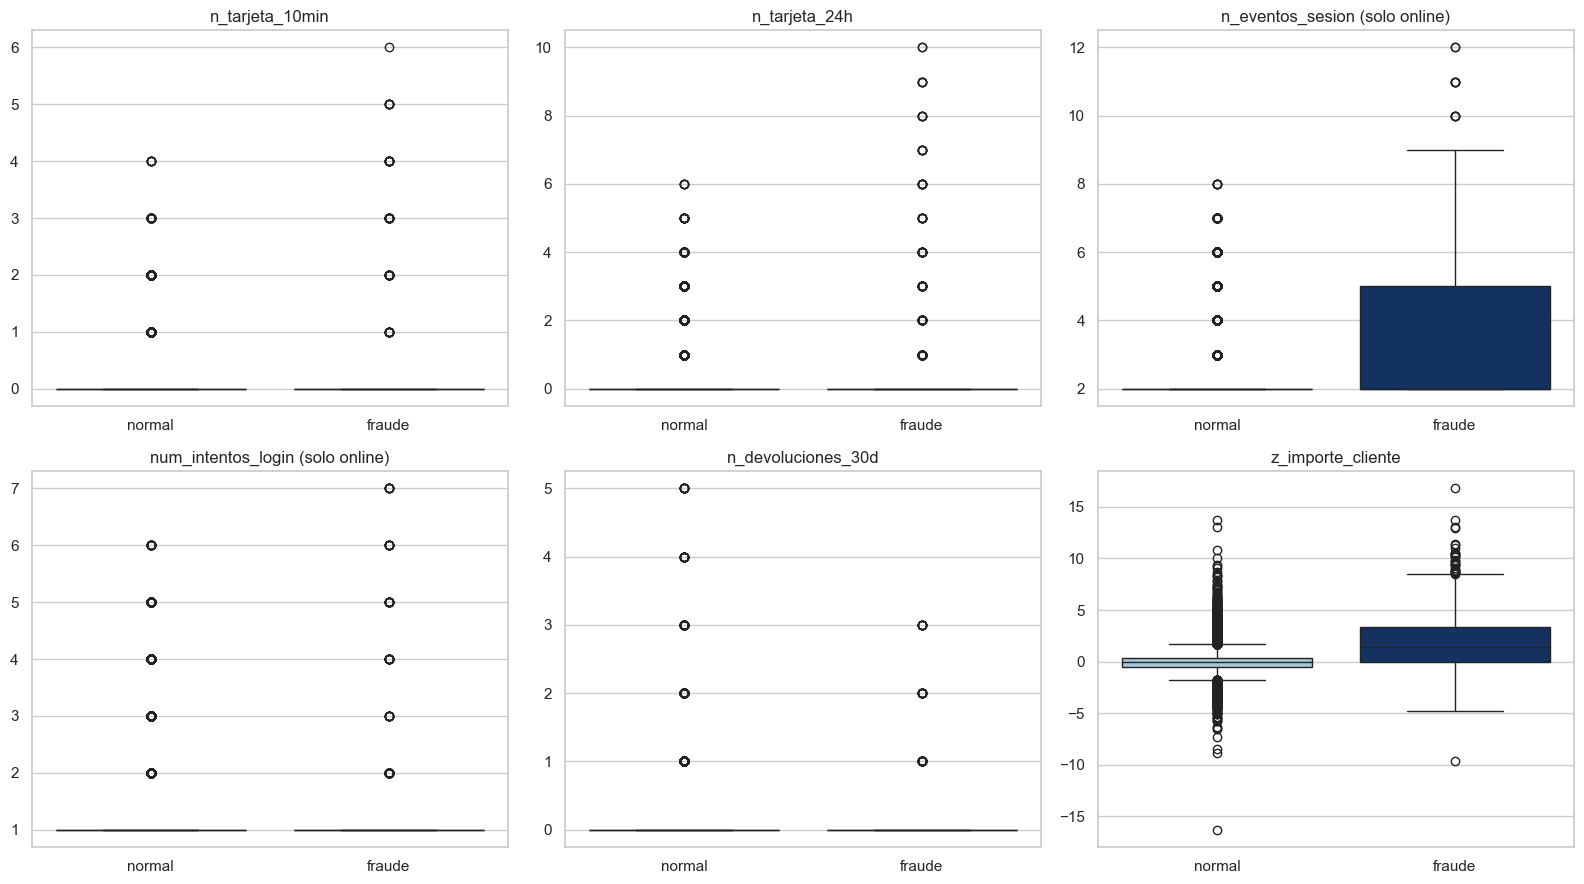

IQR n_eventos_sesion con los presenciales incluidos: marcaría 15,249 transacciones; solo online: 6,269
IQR num_intentos_login con los presenciales incluidos: marcaría 12,732 transacciones; solo online: 3,752


,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,IQR n_tarjeta_10min,1404,3.5,68,4.8,9.7
1,IQR n_tarjeta_24h,6721,16.9,158,2.4,22.5
2,IQR n_eventos_sesion,6269,15.7,270,4.3,38.4
3,IQR num_intentos_login,3752,9.4,110,2.9,15.6
4,IQR n_devoluciones_30d,2101,5.3,63,3.0,9.0
5,IQR z_importe_cliente,3237,8.1,330,10.2,46.9


In [6]:
online = df[df["es_online"] == 1]
VARIABLES_SESION = ["n_eventos_sesion", "num_intentos_login"]
VARIABLES = ["n_tarjeta_10min", "n_tarjeta_24h", "n_eventos_sesion", "num_intentos_login",
             "n_devoluciones_30d", "z_importe_cliente"]

def datos_de(var):
    return online if var in VARIABLES_SESION else df

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, var in zip(axes.flat, VARIABLES):
    sns.boxplot(data=datos_de(var), x="clase", y=var, hue="clase", order=["normal", "fraude"],
                palette=CLASES, legend=False, ax=ax)
    ax.set_title(var + (" (solo online)" if var in VARIABLES_SESION else ""))
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

iqr_otras = pd.DataFrame([
    evaluar(fuera_iqr(datos_de(v)[v]).reindex(df.index, fill_value=False), f"IQR {v}") for v in VARIABLES
])
for v in VARIABLES_SESION:
    print(f"IQR {v} con los presenciales incluidos: marcaría {int(fuera_iqr(df[v]).sum()):,} "
          f"transacciones; solo online: {int(fuera_iqr(online[v]).sum()):,}")
iqr_otras.round(1)

Variables de conteo: casi todos los valores son iguales (2 eventos por sesión, 1 intento de login, 0 pagos previos), así que el IQR tiene una caja de anchura 0 y cualquier valor distinto sale como outlier.

Analizar las variables de sesión solo con los pagos online lo reduce mucho: el IQR de n_eventos_sesion pasa de 15.249 transacciones marcadas a 6.269, y el de num_intentos_login de 12.732 a 3.752. Los ceros de los pagos con datáfono no eran outliers, eran "no aplica".

Aun así, el IQR sigue sin servir como regla en estas variables: n_eventos_sesion captura el 38,4 % del fraude, pero con un 4,3 % de precisión. Al combinarlas con el importe sí aportan (apartado 3).

**Conclusiones de los outliers univariantes**

- Ningún método univariante basta. El más equilibrado (IQR sobre el logaritmo) detecta el 51,9 % del fraude con un 41,1 % de precisión: o se detecta poco, o hay muchas falsas alarmas.
- El IQR es más robusto que el Z-score porque no asume normalidad, pero sobre el importe sin transformar marca el 7,5 % de todas las transacciones.
- El IQR no sirve para variables de conteo: cualquier valor distinto del habitual sale como outlier.
- Los valores imputados (0 en las variables de sesión de los pagos presenciales) hay que excluirlos del análisis de outliers.
- Los outliers no se eliminan: en detección de fraude son justo los casos que interesan.

## 2. Patrones simples de fraude

A diferencia de los outliers, aquí cada transacción no se compara con todas las demás, sino con su propio contexto: el historial de ese cliente y lo que ha pasado con esa tarjeta o en esa sesión en los minutos anteriores.

**Índice**
1. Pico de gasto
2. Ráfagas
3. Velocidad dentro de la sesión
4. Comparativa de patrones
5. Qué tipo de fraude detecta cada patrón
6. Combinación de patrones

### 2.1. Pico de gasto respecto al cliente

z_importe_cliente mide cuánto se aleja el importe del gasto habitual de ese cliente, usando solo sus compras anteriores. Un pago de 300 € no es raro en el conjunto, pero sí para alguien que siempre gasta 20 €.

In [7]:
def comparar_umbrales(col, umbrales, etiqueta):
    return pd.DataFrame([evaluar(df[col] >= u, f"{etiqueta} >= {u}") for u in umbrales])

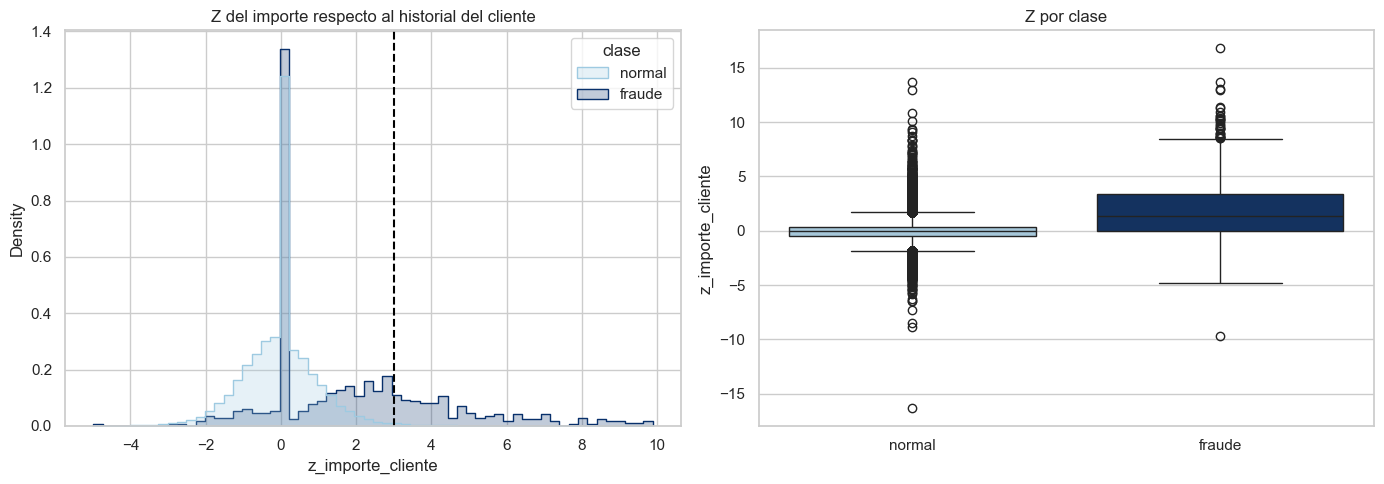

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df[df["z_importe_cliente"].between(-5, 10)], x="z_importe_cliente", hue="clase",
             palette=CLASES, bins=60, stat="density", common_norm=False, element="step", ax=axes[0])
axes[0].axvline(3, color="black", linestyle="--")
axes[0].set_title("Z del importe respecto al historial del cliente")
sns.boxplot(data=df, x="clase", y="z_importe_cliente", hue="clase", order=["normal", "fraude"],
            palette=CLASES, legend=False, ax=axes[1])
axes[1].set_title("Z por clase")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

In [9]:
comparar_umbrales("z_importe_cliente", [2, 3, 4, 5], "z cliente").round(1)

,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,z cliente >= 2,1435,3.6,298,20.8,42.4
1,z cliente >= 3,578,1.5,199,34.4,28.3
2,z cliente >= 4,295,0.7,134,45.4,19.1
3,z cliente >= 5,157,0.4,86,54.8,12.2


### 2.2. Ráfagas con la misma tarjeta

Cuántos pagos se han hecho con la misma tarjeta en los 10 minutos y en las 24 horas anteriores. Una persona rara vez paga cinco veces seguidas con la misma tarjeta; un bot probando si funciona, sí.

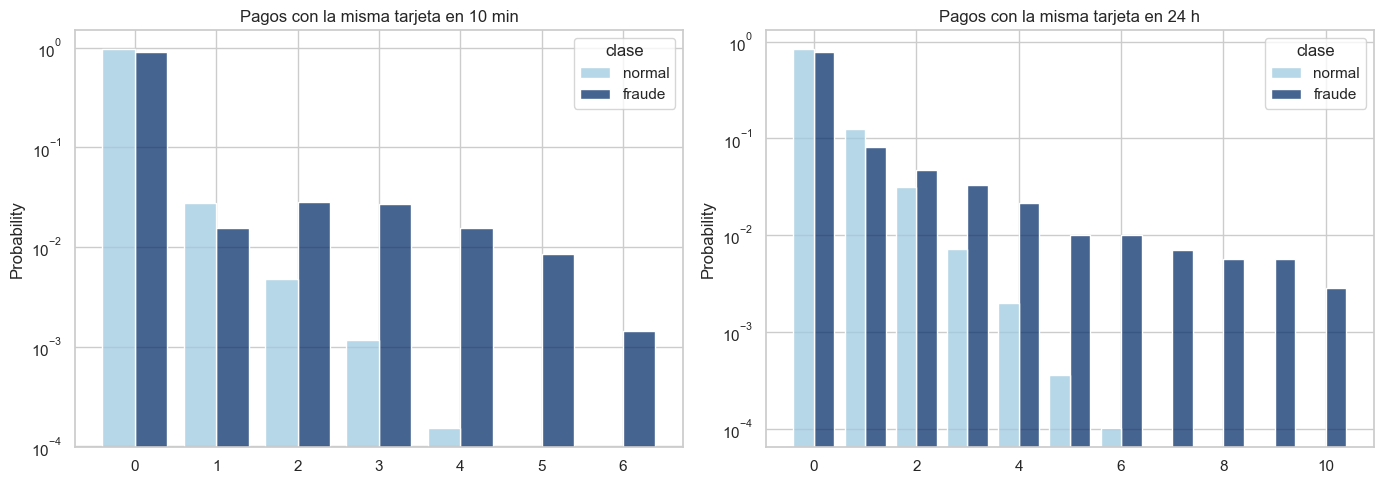

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, titulo in zip(axes, ["n_tarjeta_10min", "n_tarjeta_24h"],
                           ["Pagos con la misma tarjeta en 10 min", "Pagos con la misma tarjeta en 24 h"]):
    sns.histplot(data=df[df[col] <= 15], x=col, hue="clase", palette=CLASES, discrete=True,
                 stat="probability", common_norm=False, multiple="dodge", shrink=0.8, ax=ax)
    ax.set_yscale("log")   # sin escala log, la barra del valor 1 aplasta el resto
    ax.set_title(titulo)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [11]:
pd.concat([comparar_umbrales("n_tarjeta_10min", [3, 5], "10 min"),
           comparar_umbrales("n_tarjeta_24h", [5, 10], "24 h")]).round(1)

,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,10 min >= 3,89,0.2,37,41.6,5.3
1,10 min >= 5,7,0.0,7,100.0,1.0
0,24 h >= 5,47,0.1,29,61.7,4.1
1,24 h >= 10,2,0.0,2,100.0,0.3


### 2.3. Velocidad dentro de la sesión

Número de eventos de la sesión e intentos de login, solo en pagos online (los presenciales no tienen sesión). Muchos eventos seguidos apuntan a un bot; muchos intentos de login, a alguien probando contraseñas.

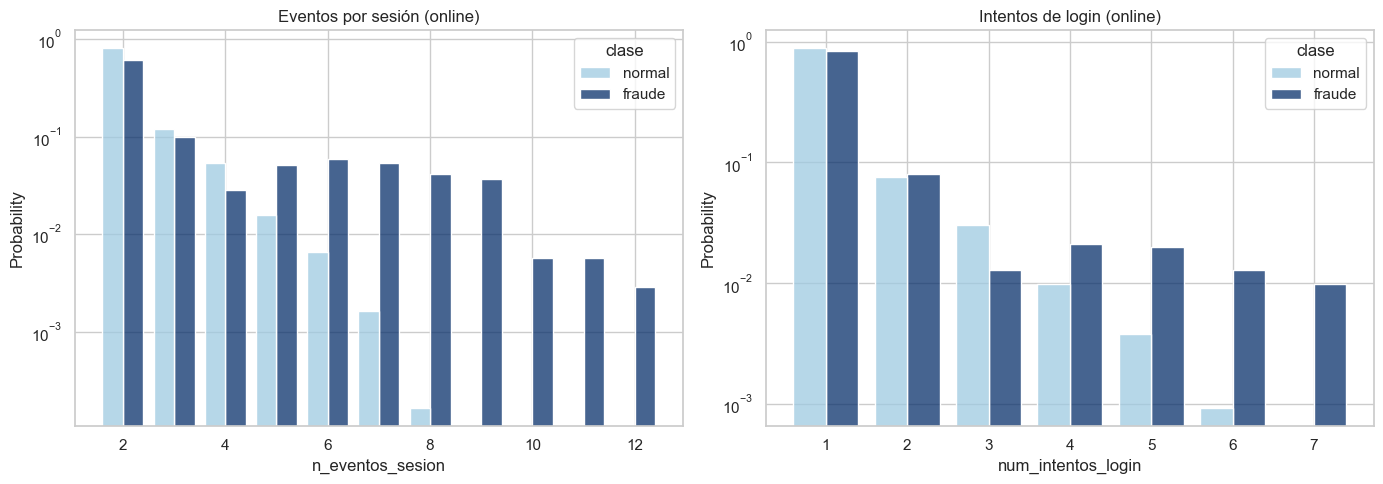

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=online[online["n_eventos_sesion"] <= 15], x="n_eventos_sesion", hue="clase",
             palette=CLASES, discrete=True, stat="probability", common_norm=False,
             multiple="dodge", shrink=0.8, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Eventos por sesión (online)")
sns.histplot(data=online[online["num_intentos_login"] <= 8], x="num_intentos_login", hue="clase",
             palette=CLASES, discrete=True, stat="probability", common_norm=False,
             multiple="dodge", shrink=0.8, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Intentos de login (online)")
plt.tight_layout()
plt.show()

In [13]:
pd.concat([comparar_umbrales("n_eventos_sesion", [5, 8, 12], "eventos sesión"),
           comparar_umbrales("num_intentos_login", [2, 3, 4], "intentos login"),
           comparar_umbrales("n_devoluciones_30d", [1, 2], "devoluciones")]).round(1)

,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,eventos sesión >= 5,905,2.3,180,19.9,25.6
1,eventos sesión >= 8,70,0.2,65,92.9,9.2
2,eventos sesión >= 12,2,0.0,2,100.0,0.3
0,intentos login >= 2,3752,9.4,110,2.9,15.6
1,intentos login >= 3,1407,3.5,54,3.8,7.7
2,intentos login >= 4,483,1.2,45,9.3,6.4
0,devoluciones >= 1,2101,5.3,63,3.0,9.0
1,devoluciones >= 2,184,0.5,24,13.0,3.4


### 2.4. Comparativa de patrones

Se fija un umbral para cada patrón: el que mejor equilibra precisión y recall en las tablas anteriores, **entre los que marcan al menos 30 transacciones**. Un umbral que marca 1 o 4 transacciones puede dar un 100 % de precisión por casualidad y no es representativo.

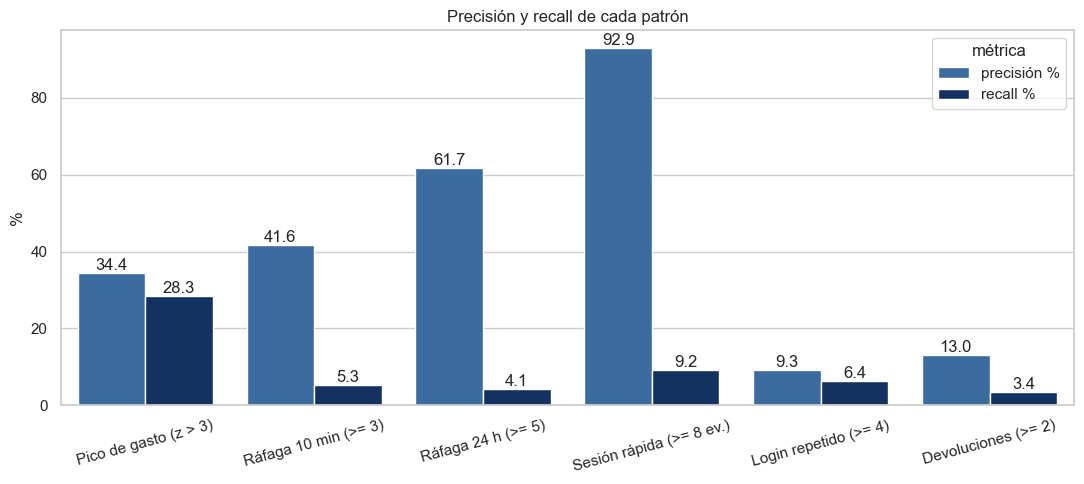

,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,Pico de gasto (z > 3),578,1.5,199,34.4,28.3
1,Ráfaga 10 min (>= 3),89,0.2,37,41.6,5.3
2,Ráfaga 24 h (>= 5),47,0.1,29,61.7,4.1
3,Sesión rápida (>= 8 ev.),70,0.2,65,92.9,9.2
4,Login repetido (>= 4),483,1.2,45,9.3,6.4
5,Devoluciones (>= 2),184,0.5,24,13.0,3.4


In [14]:
MIN_MARCADAS = 30
REGLAS = {
    "Pico de gasto (z > 3)": df["z_importe_cliente"] > 3,
    "Ráfaga 10 min (>= 3)": df["n_tarjeta_10min"] >= 3,
    "Ráfaga 24 h (>= 5)": df["n_tarjeta_24h"] >= 5,
    "Sesión rápida (>= 8 ev.)": df["n_eventos_sesion"] >= 8,
    "Login repetido (>= 4)": df["num_intentos_login"] >= 4,
    "Devoluciones (>= 2)": df["n_devoluciones_30d"] >= 2,
}
comparativa = pd.DataFrame([evaluar(m, n) for n, m in REGLAS.items()])
pocas = comparativa.loc[comparativa["marcadas"] < MIN_MARCADAS, "método"].tolist()
if pocas:
    print(f"¡OJO! Reglas con menos de {MIN_MARCADAS} transacciones marcadas: {pocas}")

fig, ax = plt.subplots(figsize=(11, 5))
larga = comparativa.melt(id_vars="método", value_vars=["precisión %", "recall %"],
                         var_name="métrica", value_name="valor")
sns.barplot(data=larga, x="método", y="valor", hue="métrica", palette=[AZUL, "#08306b"], ax=ax)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f")
ax.set_title("Precisión y recall de cada patrón")
ax.set_xlabel("")
ax.set_ylabel("%")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

comparativa.round(1)

### 2.5. Qué tipo de fraude detecta cada patrón

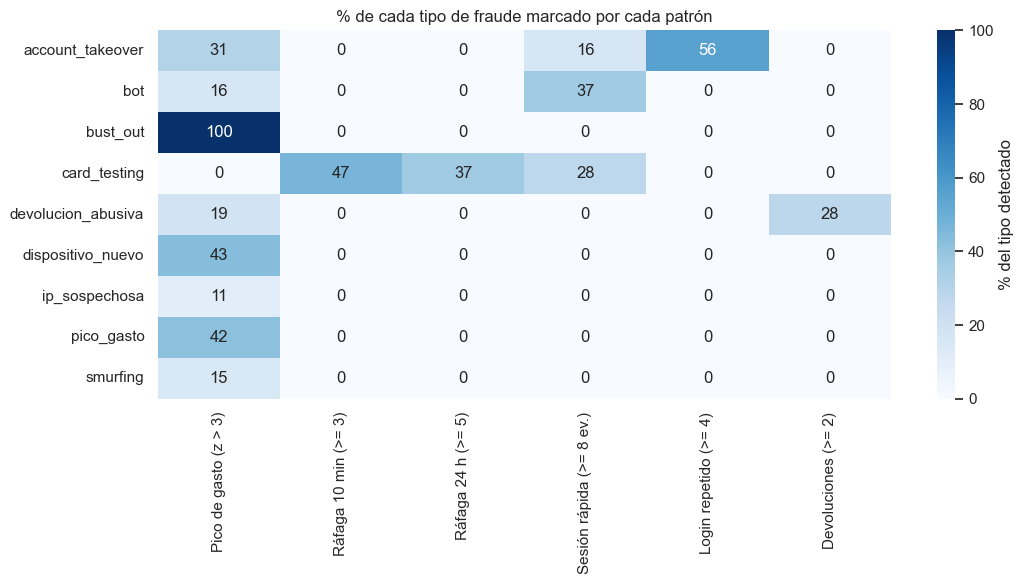

,Pico de gasto (z > 3),Ráfaga 10 min (>= 3),Ráfaga 24 h (>= 5),Sesión rápida (>= 8 ev.),Login repetido (>= 4),Devoluciones (>= 2)
tipo_fraude,,,,,,
account_takeover,31.0,0.0,0.0,16.0,56.0,0.0
bot,16.0,0.0,0.0,37.0,0.0,0.0
bust_out,100.0,0.0,0.0,0.0,0.0,0.0
card_testing,0.0,47.0,37.0,28.0,0.0,0.0
devolucion_abusiva,19.0,0.0,0.0,0.0,0.0,28.0
dispositivo_nuevo,43.0,0.0,0.0,0.0,0.0,0.0
ip_sospechosa,11.0,0.0,0.0,0.0,0.0,0.0
pico_gasto,42.0,0.0,0.0,0.0,0.0,0.0
smurfing,15.0,0.0,0.0,0.0,0.0,0.0


In [15]:
fraude = df[df["es_fraude"] == 1]
por_tipo = pd.DataFrame({n: m[fraude.index].groupby(fraude["tipo_fraude"]).mean() * 100
                         for n, m in REGLAS.items()}).astype(float)
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(por_tipo, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100,
            cbar_kws={"label": "% del tipo detectado"}, ax=ax)
ax.set_title("% de cada tipo de fraude marcado por cada patrón")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

por_tipo.round(0)

## 3. Técnicas estadísticas para detección de anomalías

Los patrones anteriores miraban una señal cada vez. Aquí se combinan todas en un único **score de anomalía**: un número por transacción que indica cómo de rara es en conjunto. Se comparan tres formas de construirlo, todas estadísticas (sin machine learning todavía).

**Índice**
1. Variables que entran en el score
2. Correlación entre variables
3. Score por suma de señales
4. Score por percentiles
5. Distancia de Mahalanobis
6. Comparativa de los tres scores
7. Umbral elegido
8. Qué se sigue escapando

### 3.1. Variables que entran en el score

Las mismas señales de los apartados anteriores, ahora como variables numéricas en vez de reglas de sí/no. Dos ajustes para que los scores no confundan "raro" con "sospechoso":

- **Pagos presenciales**: no tienen sesión y features.py les pone 0 eventos y 0 intentos de login. Ese 0 se sustituye por la mediana de los pagos online (valor neutro); si no, Mahalanobis los vería lejos del centro.
- **Importe por debajo de lo habitual**: gastar mucho menos de lo normal no es fraude. El z-score del cliente se recorta en 0, así que solo cuenta la cola alta.

In [16]:
VARIABLES = ["z_importe_cliente", "n_tarjeta_10min", "n_tarjeta_24h",
             "n_eventos_sesion", "num_intentos_login", "n_devoluciones_30d"]
X = df[VARIABLES].astype(float)
presencial = df["es_online"] == 0
for v in VARIABLES_SESION:
    X.loc[presencial, v] = X.loc[~presencial, v].median()
X["z_importe_cliente"] = X["z_importe_cliente"].clip(lower=0)
X.describe().round(2)

,z_importe_cliente,n_tarjeta_10min,n_tarjeta_24h,n_eventos_sesion,num_intentos_login,n_devoluciones_30d
count,39839.00,39839.00,39839.00,39839.00,39839.00,39839.00
mean,0.35,0.05,0.23,2.26,1.15,0.06
std,0.79,0.27,0.60,0.73,0.53,0.28
min,0.00,0.00,0.00,2.00,1.00,0.00
25%,0.00,0.00,0.00,2.00,1.00,0.00
50%,0.00,0.00,0.00,2.00,1.00,0.00
75%,0.41,0.00,0.00,2.00,1.00,0.00
max,16.78,6.00,10.00,12.00,7.00,5.00


### 3.2. Correlación entre variables

Si dos variables están muy correlacionadas miden casi lo mismo, y al sumarlas en un score ese aspecto cuenta doble.

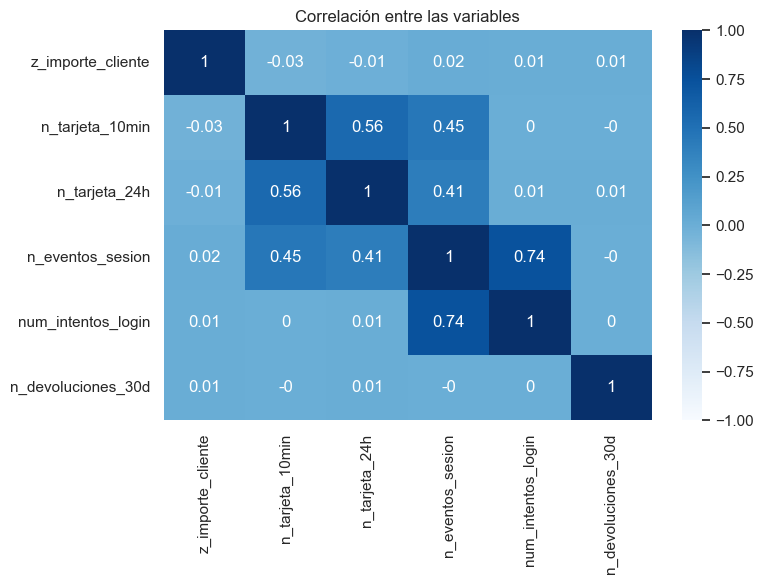

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(X.corr().round(2), annot=True, cmap="Blues", vmin=-1, vmax=1, center=0, ax=ax)
ax.set_title("Correlación entre las variables")
plt.tight_layout()
plt.show()

### 3.3. Score por suma de señales

El más simple: cada señal aporta 1 punto si se activa, así que el score va de 0 a 4.

La ráfaga usa aquí un umbral más bajo (≥ 3 pagos en 10 min) que en la comparativa de patrones (≥ 5). Como regla aislada, ≥ 3 da demasiadas falsas alarmas. Como una señal más de un score, basta con que sume un punto.


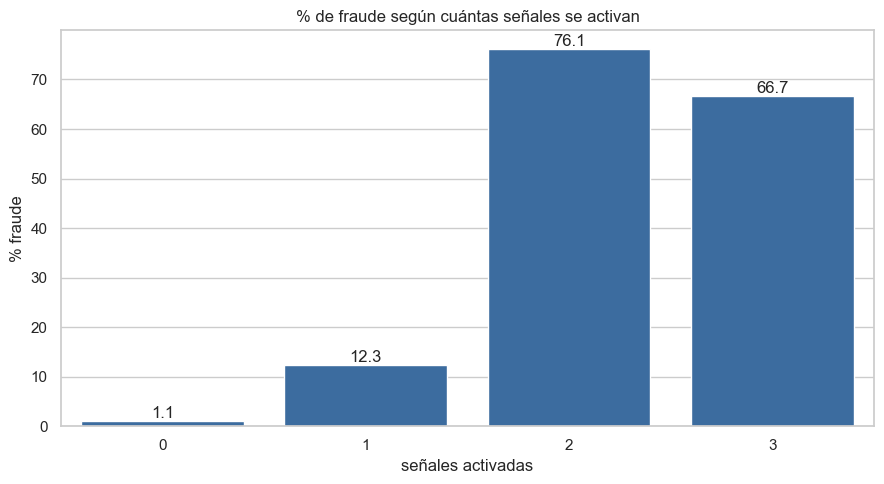

,score_señales,transacciones,fraudes,% fraude
0,0,37768,403,1.1
1,1,2001,247,12.3
2,2,67,51,76.1
3,3,3,2,66.7


In [18]:
SENALES = {
    "importe anómalo": X["z_importe_cliente"] > 3,
    "ráfaga tarjeta": X["n_tarjeta_10min"] >= 3,
    "sesión rápida": X["n_eventos_sesion"] >= 8,
    "login repetido": X["num_intentos_login"] >= 3,
}
df["score_señales"] = sum(s.astype(int) for s in SENALES.values())

resumen = (df.groupby("score_señales")
             .agg(transacciones=("es_fraude", "size"), fraudes=("es_fraude", "sum"))
             .reset_index())
resumen["% fraude"] = (resumen["fraudes"] / resumen["transacciones"] * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=resumen, x="score_señales", y="% fraude", color=AZUL, ax=ax)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f")
ax.set_title("% de fraude según cuántas señales se activan")
ax.set_xlabel("señales activadas")
plt.tight_layout()
plt.show()

resumen

### 3.4. Score por percentiles

Cada variable se convierte a su percentil (de 0 a 1), lo que las pone a todas en la misma escala aunque una vaya en euros y otra en número de eventos. El score es el percentil más alto de sus variables: basta con destacar en una para ser sospechosa.

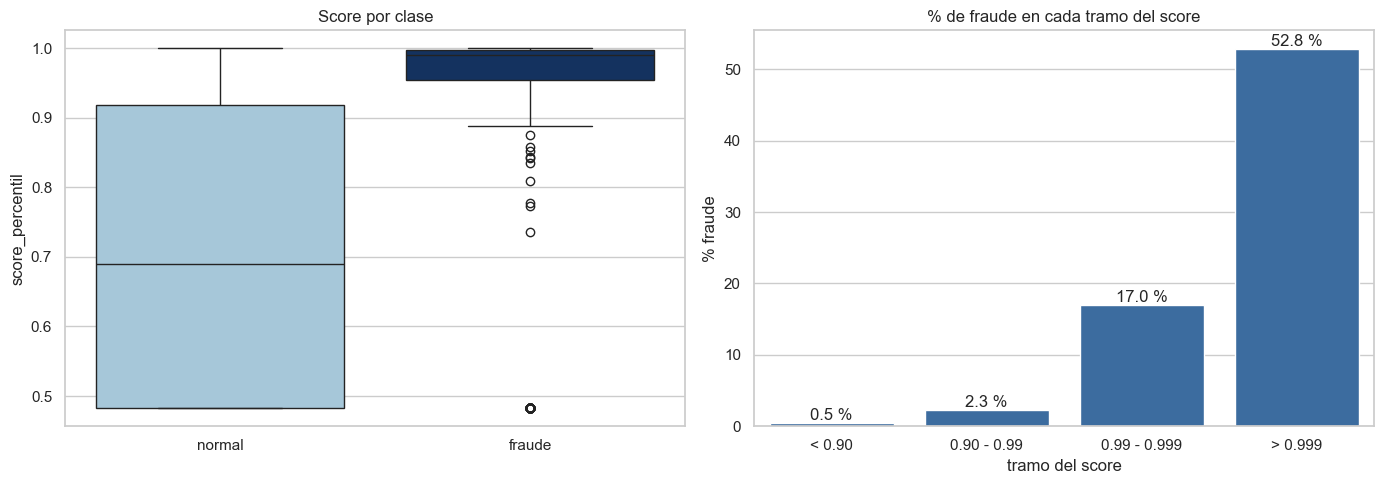

,score_percentil,transacciones,fraudes,% fraude
0,< 0.90,28914,140,0.5
1,0.90 - 0.99,9218,209,2.3
2,0.99 - 0.999,1527,259,17.0
3,> 0.999,180,95,52.8


In [19]:
percentiles = X.rank(pct=True)
df["score_percentil"] = percentiles.max(axis=1)

# Tramos del score: el 90 % más bajo, y luego los tres escalones superiores
tramos = pd.cut(df["score_percentil"], [0, 0.9, 0.99, 0.999, 1.0],
                labels=["< 0.90", "0.90 - 0.99", "0.99 - 0.999", "> 0.999"])
por_tramo = (df.groupby(tramos, observed=True)
               .agg(transacciones=("es_fraude", "size"), fraudes=("es_fraude", "sum"))
               .reset_index())
por_tramo["% fraude"] = (por_tramo["fraudes"] / por_tramo["transacciones"] * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="clase", y="score_percentil", hue="clase", order=["normal", "fraude"],
            palette=CLASES, legend=False, ax=axes[0])
axes[0].set_title("Score por clase")
axes[0].set_xlabel("")

sns.barplot(data=por_tramo, x="score_percentil", y="% fraude", color=AZUL, ax=axes[1])
for cont in axes[1].containers:
    axes[1].bar_label(cont, fmt="%.1f %%")
axes[1].set_title("% de fraude en cada tramo del score")
axes[1].set_xlabel("tramo del score")
plt.tight_layout()
plt.show()

por_tramo

In [20]:
pd.DataFrame([evaluar(df["score_percentil"] >= u, f"percentil >= {u}")
              for u in [0.95, 0.99, 0.995, 0.999]]).round(1)

,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,percentil >= 0.95,7450,18.7,529,7.1,75.2
1,percentil >= 0.99,1707,4.3,354,20.7,50.4
2,percentil >= 0.995,951,2.4,262,27.5,37.3
3,percentil >= 0.999,180,0.5,95,52.8,13.5


### 3.5. Distancia de Mahalanobis

La técnica multivariante clásica. Mide a qué distancia está cada transacción del "centro" de los datos, teniendo en cuenta que las variables están correlacionadas: dos valores altos a la vez cuentan menos si esas dos variables suelen subir juntas.

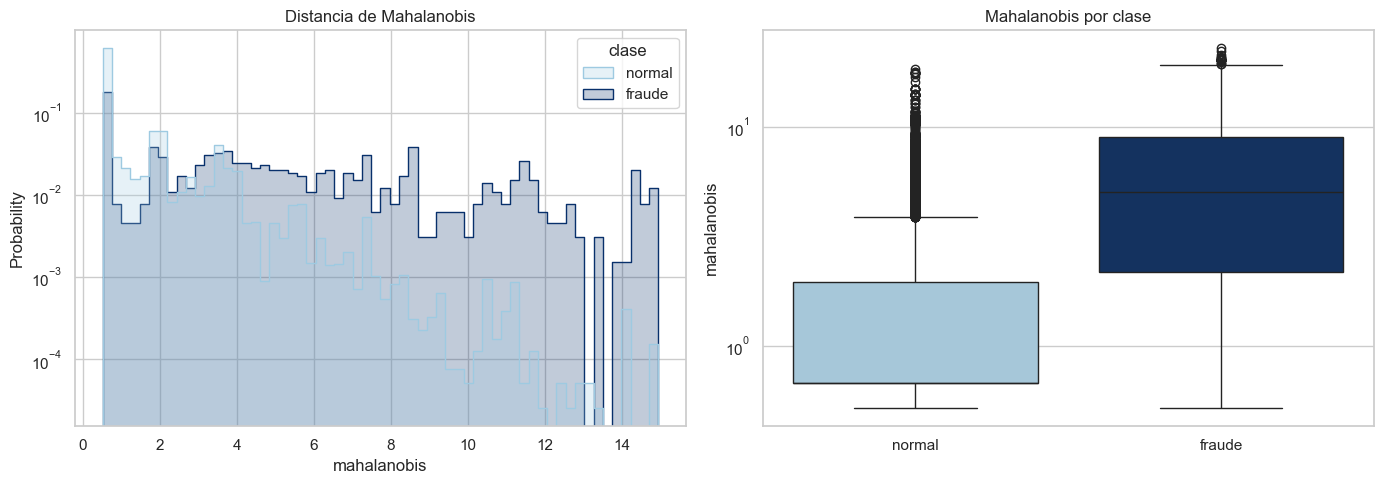

,método,marcadas,% del total,fraude detectado,precisión %,recall %
0,mahalanobis >= 3,6537,16.4,493,7.5,70.1
1,mahalanobis >= 5,2067,5.2,353,17.1,50.2
2,mahalanobis >= 8,504,1.3,220,43.7,31.3
3,mahalanobis >= 12,137,0.3,96,70.1,13.7


In [21]:
media = X.mean()
cov_inv = np.linalg.pinv(X.cov().values)   # pinv: tolera variables muy correlacionadas
centrada = (X - media).values
df["mahalanobis"] = np.sqrt(np.einsum("ij,jk,ik->i", centrada, cov_inv, centrada))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df[df["mahalanobis"] < 15], x="mahalanobis", hue="clase", palette=CLASES,
             bins=60, stat="probability", common_norm=False, element="step", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Distancia de Mahalanobis")
sns.boxplot(data=df, x="clase", y="mahalanobis", hue="clase", order=["normal", "fraude"],
            palette=CLASES, legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Mahalanobis por clase")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

pd.DataFrame([evaluar(df["mahalanobis"] >= u, f"mahalanobis >= {u}")
              for u in [3, 5, 8, 12]]).round(1)

### 3.6. Comparativa de los tres scores

Cada punto es un umbral distinto. Cuanto más arriba y a la derecha esté la curva, mejor es el score. La línea gris es la precisión que se obtendría marcando transacciones al azar.

La suma de señales solo vale de 0 a 4, así que no tiene 60 umbrales distintos: se usan sus valores posibles (sin el 0, que marcaría todas las transacciones).

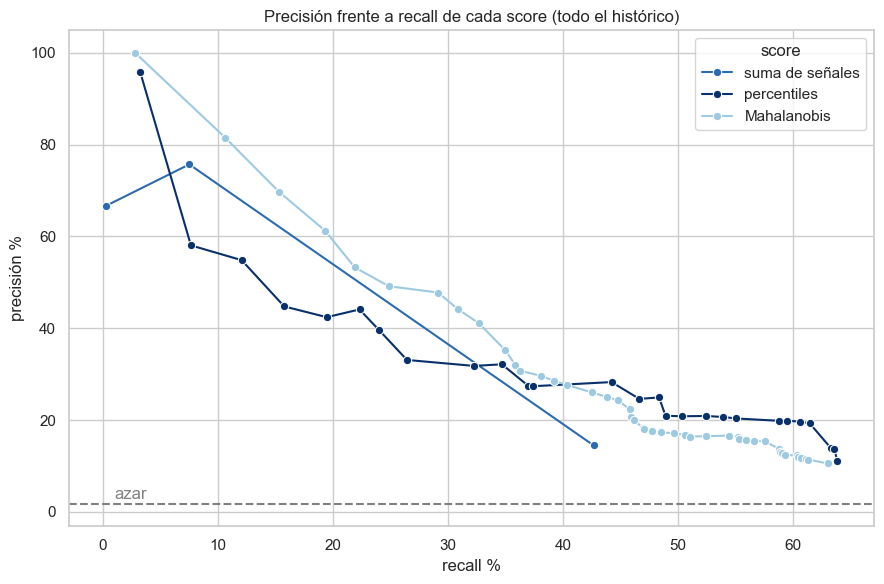

,PR-AUC,ROC-AUC
suma de señales,0.118,0.692
percentiles,0.263,0.827
Mahalanobis,0.305,0.837


In [22]:
def curva(score, nombre, pasos=60):
    if score.nunique() <= pasos:
        umbrales = np.sort(score.unique())[1:]
    else:
        umbrales = score.quantile(np.linspace(0.90, 0.9995, pasos)).unique()
    filas = []
    for u in umbrales:
        marcadas = score >= u
        n = int(marcadas.sum())
        vp = int((marcadas & (df["es_fraude"] == 1)).sum())
        if n:
            filas.append({"score": nombre, "precisión %": vp / n * 100,
                          "recall %": vp / TOTAL_FRAUDE * 100})
    return pd.DataFrame(filas)

SCORES = {"suma de señales": "score_señales", "percentiles": "score_percentil", "Mahalanobis": "mahalanobis"}
curvas = pd.concat([curva(df[col], nombre) for nombre, col in SCORES.items()])

fig, ax = plt.subplots(figsize=(9, 6))
sns.lineplot(data=curvas, x="recall %", y="precisión %", hue="score", marker="o",
             palette=[AZUL, "#08306b", "#9ecae1"], ax=ax)
ax.axhline(df["es_fraude"].mean() * 100, color="grey", linestyle="--")
ax.text(1, df["es_fraude"].mean() * 100 + 1, "azar", color="grey")
ax.set_title("Precisión frente a recall de cada score (todo el histórico)")
plt.tight_layout()
plt.show()

pd.DataFrame({nombre: {"PR-AUC": average_precision_score(df["es_fraude"], df[col]),
                       "ROC-AUC": roc_auc_score(df["es_fraude"], df[col])}
              for nombre, col in SCORES.items()}).T.round(3)

### 3.7. Umbral elegido 

Hasta aquí todo se ha calculado sobre el histórico completo, así que las cifras son optimistas. Para que sirva de referencia, cada score se trata como un modelo más, con el mismo procedimiento que comparacion_modelos.py:

- Se usa la misma partición que preparacion_datos_ml.py (sin los días de calentamiento; 70 % train, 30 % test).
- Los percentiles y la media y covarianza de Mahalanobis se calculan solo con train.
- El umbral es el percentil 99 del score en train (presupuesto del 1 %) y se aplica tal cual al test.
- Se mide en test: PR-AUC, ROC-AUC, precisión y recall.

In [ ]:
train = df[df["parte"] == "train"]
test = df[df["parte"] == "test"]
X_train, X_test = X.loc[train.index], X.loc[test.index]

def score_percentil_ref(Xs, ref):
    pct = {}
    for v in Xs.columns:
        orden = np.sort(ref[v].values)
        izq = np.searchsorted(orden, Xs[v].values, side="left")
        der = np.searchsorted(orden, Xs[v].values, side="right")
        pct[v] = (izq + der) / 2 / len(orden)
    return pd.DataFrame(pct, index=Xs.index).max(axis=1)

def mahalanobis_ref(Xs, ref):
    cov_inv = np.linalg.pinv(ref.cov().values)
    c = (Xs - ref.mean()).values
    return pd.Series(np.sqrt(np.einsum("ij,jk,ik->i", c, cov_inv, c)), index=Xs.index)

scores_ref = {
    "suma de señales": (df.loc[train.index, "score_señales"], df.loc[test.index, "score_señales"]),
    "percentiles": (score_percentil_ref(X_train, X_train), score_percentil_ref(X_test, X_train)),
    "Mahalanobis": (mahalanobis_ref(X_train, X_train), mahalanobis_ref(X_test, X_train)),
}

filas = []
for nombre, (s_train, s_test) in scores_ref.items():
    umbral = np.quantile(s_train, 0.99)
    fila = evaluar((s_test >= umbral).reindex(df.index, fill_value=False), nombre, test)
    fila.update({"umbral p99 train": umbral,
                 "PR-AUC train": average_precision_score(train["es_fraude"], s_train),
                 "PR-AUC test": average_precision_score(test["es_fraude"], s_test),
                 "ROC-AUC test": roc_auc_score(test["es_fraude"], s_test)})
    filas.append(fila)
referencia = pd.DataFrame(filas)

ELEGIDO = referencia.loc[referencia["PR-AUC train"].idxmax(), "método"]
s_train, s_test = scores_ref[ELEGIDO]
UMBRAL = np.quantile(s_train, 0.99)
test = test.assign(score=s_test, sospechosa=s_test >= UMBRAL)
print(f"Score elegido (mejor PR-AUC en train): {ELEGIDO}   umbral p99 de train: {UMBRAL:.4f}\n")
display(referencia.round(3))

pd.crosstab(test["es_fraude"].map({0: "real: normal", 1: "real: fraude"}),
            test["sospechosa"].map({False: "pred: normal", True: "pred: sospechosa"}))

Score elegido (mejor PR-AUC en train): Mahalanobis   umbral p99 de train: 8.8388



,método,marcadas,% del total,fraude detectado,precisión %,recall %,umbral p99 train,PR-AUC train,PR-AUC test,ROC-AUC test
0,suma de señales,579,5.829,106,18.307,47.748,1.000,0.117,0.159,0.716
1,percentiles,118,1.188,52,44.068,23.423,0.998,0.260,0.323,0.867
2,Mahalanobis,109,1.097,56,51.376,25.225,8.839,0.302,0.355,0.870


sospechosa,pred: normal,pred: sospechosa
es_fraude,,
real: fraude,166,56
real: normal,9658,53


Comparación con los modelos de los hitos 3 y 4, medidos con el mismo test y el mismo presupuesto del 1 % (resultados/comparativa_test.csv, generado por evaluar_modelos_nosupervisados.py).

In [ ]:
modelos = pd.read_csv("../resultados/comparativa_test.csv")
modelos = modelos[~modelos["detector"].str.contains(r"\(")]   
tabla = pd.concat([
    pd.DataFrame({"detector": f"estadístico: {r['método']}", "PR-AUC": r["PR-AUC test"],
                  "ROC-AUC": r["ROC-AUC test"], "precisión % (1 %)": r["precisión %"],
                  "recall % (1 %)": r["recall %"]} for _, r in referencia.iterrows()),
    pd.DataFrame({"detector": modelos["detector"], "PR-AUC": modelos["PR-AUC"], "ROC-AUC": modelos["ROC-AUC"],
                  "precisión % (1 %)": modelos["pres_precision_%"], "recall % (1 %)": modelos["pres_recall_%"]}),
]).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
tabla.round(3)

,detector,PR-AUC,ROC-AUC,precisión % (1 %),recall % (1 %)
0,kmeans,0.498,0.960,64.865,35.036
1,estadístico: Mahalanobis,0.355,0.870,51.376,25.225
2,iforest,0.350,0.910,52.239,25.547
3,estadístico: percentiles,0.323,0.867,44.068,23.423
4,ocsvm,0.244,0.899,44.444,26.277
5,estadístico: suma de señales,0.159,0.716,18.307,47.748


### 3.8. Qué se sigue escapando

Porcentaje de cada tipo de fraude del **test** que marca el umbral elegido. Hay unas 20-30 transacciones de cada tipo en test, así que cada transacción mueve el porcentaje varios puntos.

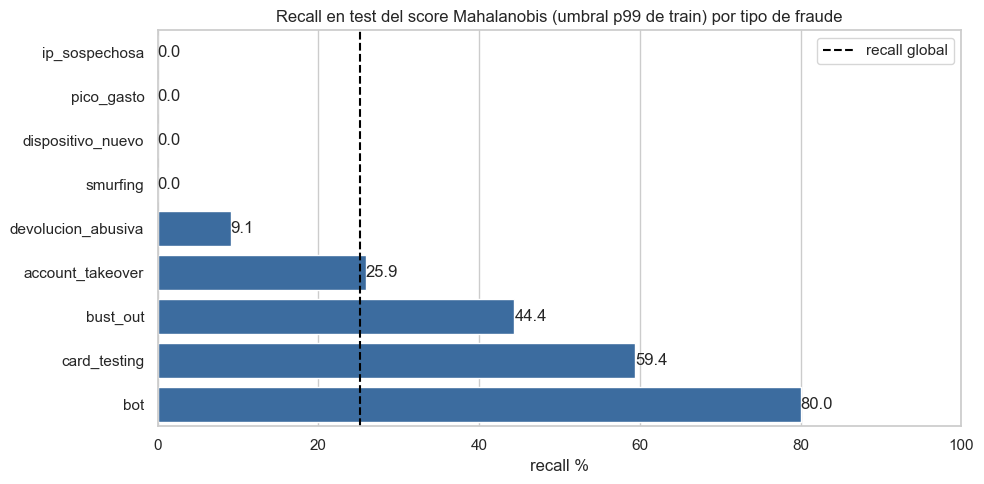

,fraudes,detectados,recall %
tipo_fraude,,,
ip_sospechosa,25,0,0.0
pico_gasto,23,0,0.0
dispositivo_nuevo,28,0,0.0
smurfing,22,0,0.0
devolucion_abusiva,22,2,9.1
account_takeover,27,7,25.9
bust_out,18,8,44.4
card_testing,32,19,59.4
bot,25,20,80.0


In [25]:
recall_tipo = (test[test["es_fraude"] == 1]
               .groupby("tipo_fraude")
               .agg(fraudes=("sospechosa", "size"), detectados=("sospechosa", "sum")))
recall_tipo["recall %"] = (recall_tipo["detectados"] / recall_tipo["fraudes"] * 100).round(1)
recall_tipo = recall_tipo.sort_values("recall %")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=recall_tipo.reset_index(), y="tipo_fraude", x="recall %", color=AZUL, ax=ax)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f")
ax.axvline(recall_tipo["detectados"].sum() / recall_tipo["fraudes"].sum() * 100,
           color="black", linestyle="--", label="recall global")
ax.set_title(f"Recall en test del score {ELEGIDO} (umbral p99 de train) por tipo de fraude")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

recall_tipo

## 4. Carga de trabajo para los analistas

Cada transacción marcada como sospechosa acabará siendo una alerta que un analista tiene que revisar. Por eso el umbral no se elige solo por precisión y recall: también tiene que generar un volumen de alertas que el equipo pueda revisar al día.

Aquí solo se lee la tabla analista para saber cuántos hay activos. Los datos de analistas **no** entran en features_transaccion ni en el dataset de ML: el veredicto de un analista se conoce después del pago y depende de si era fraude, así que como variable sería fuga de información.


Analistas activos: 6   Días de datos: 180   Alertas en la tabla alerta: 1491 (las genera reglas_alerta.py)



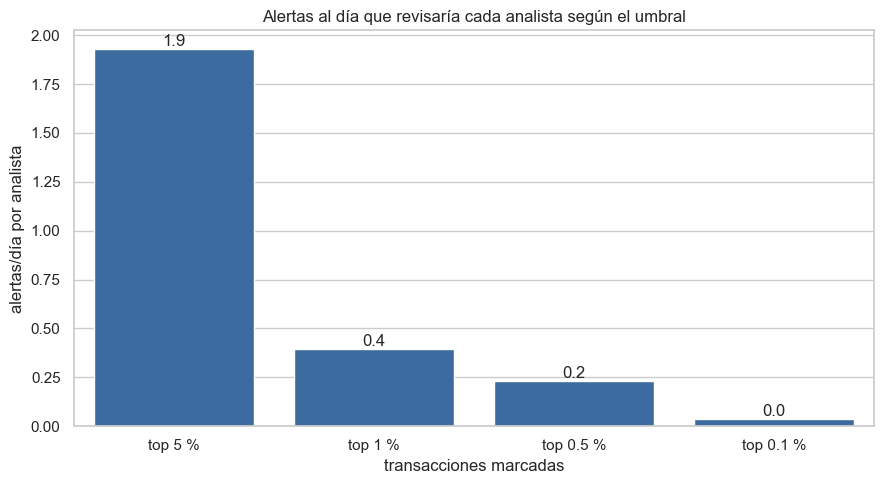

,método,marcadas,alertas/día,alertas/día por analista,precisión %,recall %
0,top 5 %,2082,11.6,1.9,19.8,58.7
1,top 1 %,427,2.4,0.4,39.6,24.0
2,top 0.5 %,248,1.4,0.2,44.8,15.8
3,top 0.1 %,40,0.2,0.0,72.5,4.1


In [26]:
n_analistas = client.command("SELECT count() FROM analista WHERE activo")
n_alertas = client.command("SELECT count() FROM alerta")
dias = (df["timestamp"].max() - df["timestamp"].min()).days + 1
print(f"Analistas activos: {n_analistas}   Días de datos: {dias}   "
      f"Alertas en la tabla alerta: {n_alertas} (las genera reglas_alerta.py)\n")

filas = []
for q in [0.95, 0.99, 0.995, 0.999]:
    marcadas = df["score_percentil"] >= df["score_percentil"].quantile(q)
    r = evaluar(marcadas, f"top {(1 - q) * 100:g} %")
    r["alertas/día"] = r["marcadas"] / dias
    r["alertas/día por analista"] = r["alertas/día"] / n_analistas
    filas.append(r)
carga = pd.DataFrame(filas)[["método", "marcadas", "alertas/día", "alertas/día por analista",
                             "precisión %", "recall %"]]

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=carga, x="método", y="alertas/día por analista", color=AZUL, ax=ax)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f")
ax.set_title("Alertas al día que revisaría cada analista según el umbral")
ax.set_xlabel("transacciones marcadas")
plt.tight_layout()
plt.show()

carga.round(1)

Bajar el umbral sube el recall, pero multiplica las alertas: hay que fijar cuántas puede revisar cada analista al día y elegir el umbral con mayor recall dentro de ese límite. Con 6 analistas, incluso marcar el 5 % supone menos de 2 alertas al día por analista, así que hay margen para bajar el umbral. La vista alertas_enriquecidas permitirá medir lo que aquí solo se estima: carga real, tiempo de revisión y concordancia del veredicto con es_fraude.